In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
def compute_cumulative_outcome_fractions(df, masses, N):
    """
    df      : DataFrame with columns ['mass', 'time', 'particle_id', 'result']
              where result is 'Ejected' or 'Captured', and each row represents
              the time at which that particle's outcome occurred
    masses  : list/array of unique mass values, in the same order as N
    N       : list/array of total particle counts, one per mass in `masses`

    Returns
    -------
    ejection_df, capture_df : DataFrames indexed by mass, columns = sorted
                               unique time values, entries = CUMULATIVE
                               fraction of N with that result by that time
                               (i.e. fraction ejected/captured at or before
                               each time, monotonically non-decreasing
                               across each row)
    """
    if len(masses) != len(N):
        raise ValueError("masses and N must be the same length")

    mass_to_N = dict(zip(masses, N))

    times = np.sort(df["time"].unique())

    ejection_df = pd.DataFrame(index=masses, columns=times, dtype=float)
    capture_df = pd.DataFrame(index=masses, columns=times, dtype=float)

    for mass in masses:
        mass_df = df[df["mass"] == mass]
        denom = mass_to_N[mass]

        counts = (
            mass_df.groupby(["time", "result"])
            .size()
            .unstack(fill_value=0)
        )

        # reindex to the full sorted time axis, filling any missing times
        # with 0 new outcomes at that time, then cumsum across time
        ejected_counts = counts.get("Ejected", pd.Series(0, index=counts.index))
        captured_counts = counts.get("Captured", pd.Series(0, index=counts.index))

        ejected_counts = ejected_counts.reindex(times, fill_value=0)
        captured_counts = captured_counts.reindex(times, fill_value=0)

        ejection_df.loc[mass] = (ejected_counts.cumsum() / denom).values
        capture_df.loc[mass] = (captured_counts.cumsum() / denom).values

    return ejection_df, capture_df

In [279]:
df=pd.read_csv('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/local_20260911_112627_ejection_results.txt', header=None)

In [280]:
df.columns=['mass','time','result']

In [281]:
ejection_df, capture_df=compute_cumulative_outcome_fractions(df, df.mass.unique(),[800,800,800,800,800,800])

ValueError: masses and N must be the same length

In [ ]:
ejection_df.index

Index([0.030027, 0.0094955, 0.00400422, 0.00168856, 0.00071206, 0.00030027], dtype='float64')

In [285]:
masses=np.logspace(-2,-5,6)
t_maxes=2.02731513e+01*masses**(-2/3) + 6.97903308e+04

In [286]:
t_maxes

array([ 70227.10260437,  70887.45196906,  72546.17457829,  76712.69739405,
        87178.52952152, 113467.51123698])

In [234]:
ejection_df

,0.000000e+00,9.991568e+02,1.998314e+03,6.998949e+03,9.853164e+03,9.998499e+03,1.083848e+04,1.182380e+04,1.280911e+04,1.293872e+04,...,1.831725e+06,1.832725e+06,1.837724e+06,1.849722e+06,1.907714e+06,2.032695e+06,2.038694e+06,2.063690e+06,2.065690e+06,2.077688e+06
0.030027,0.0,0.0,0.0,0.0,0.00125,0.00125,0.01125,0.03875,0.06875,0.06875,...,0.91500,0.91500,0.91500,0.91500,0.91500,0.91500,0.91500,0.91500,0.91500,0.91500
0.009496,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00125,...,0.84375,0.84375,0.84375,0.84375,0.84375,0.84375,0.84375,0.84375,0.84375,0.84375
0.004004,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.83625,0.83625,0.83625,0.83625,0.83625,0.83625,0.83625,0.83625,0.83625,0.83625
0.001689,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.86500,0.86500,0.86500,0.86500,0.86500,0.86500,0.86500,0.86500,0.86500,0.86500
0.000712,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.86000,0.86000,0.86000,0.86000,0.86000,0.86000,0.86000,0.86000,0.86000,0.86000
0.000300,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.84000,0.84125,0.84250,0.84250,0.84375,0.84500,0.84625,0.84750,0.84875,0.85000


In [235]:
capture_df

,0.000000e+00,9.991568e+02,1.998314e+03,6.998949e+03,9.853164e+03,9.998499e+03,1.083848e+04,1.182380e+04,1.280911e+04,1.293872e+04,...,1.831725e+06,1.832725e+06,1.837724e+06,1.849722e+06,1.907714e+06,2.032695e+06,2.038694e+06,2.063690e+06,2.065690e+06,2.077688e+06
0.030027,0.02875,0.02875,0.02875,0.02875,0.02875,0.02875,0.02875,0.02875,0.02875,0.02875,...,0.03125,0.03125,0.03125,0.03125,0.03125,0.03125,0.03125,0.03125,0.03125,0.03125
0.009496,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,...,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875
0.004004,0.01250,0.01250,0.01250,0.01250,0.01250,0.01250,0.01250,0.01250,0.01250,0.01250,...,0.01250,0.01250,0.01250,0.01250,0.01250,0.01250,0.01250,0.01250,0.01250,0.01250
0.001689,0.00625,0.00750,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,...,0.01000,0.01000,0.01000,0.01000,0.01000,0.01000,0.01000,0.01000,0.01000,0.01000
0.000712,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,...,0.01000,0.01000,0.01000,0.01000,0.01000,0.01000,0.01000,0.01000,0.01000,0.01000
0.000300,0.00000,0.00000,0.00000,0.00125,0.00125,0.00250,0.00250,0.00250,0.00250,0.00250,...,0.00750,0.00750,0.00750,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875


In [278]:
e_scale=0.1
p=0.99
e_p=e_scale*np.sqrt(-2*np.log(1-p))
e_p

0.30348542587702926

In [260]:
t_scale=np.array([100_000,
100_000,
180_000,400_000,
1_000_000,
4_000_000])
masses=np.array([0.030027,
        0.0094955,
        0.00400422,
        0.00168856,
        0.00071206,
        0.00030027])

In [261]:
def mm_t_scaling(m, a,b):
    return a*m**(-3/2)+b

In [262]:
popt,pcov=curve_fit(mm_t_scaling,masses,t_scale)

In [287]:
masses=np.logspace(-2,-5,6)
t_maxes=2.02731513e+01*masses**(-3/2)+ 6.97903308e+04

In [288]:
t_maxes

array([9.00634821e+04, 2.30825696e+05, 1.34893970e+06, 1.02304349e+07,
       8.07786594e+07, 6.41163125e+08])

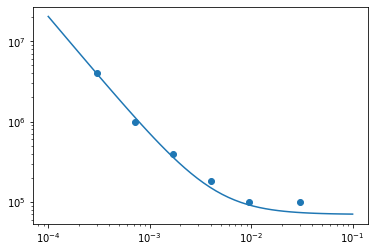

In [267]:
m=np.logspace(-4,-1)
plt.scatter(masses,t_scale)
plt.plot(m,mm_t_scaling(m,popt[0],popt[1]))
plt.xscale('log')
plt.yscale('log')

In [254]:
masses=np.logspace(-5,-2,6)


In [255]:
masses

array([1.00000000e-05, 3.98107171e-05, 1.58489319e-04, 6.30957344e-04,
       2.51188643e-03, 1.00000000e-02])

In [268]:
masses=np.logspace(-5,-2,6)

In [269]:
crit_e=2.1*masses**(1/4)

In [270]:
crit_e

array([0.11809168, 0.16680893, 0.23562388, 0.33282757, 0.47013144,
       0.66407831])

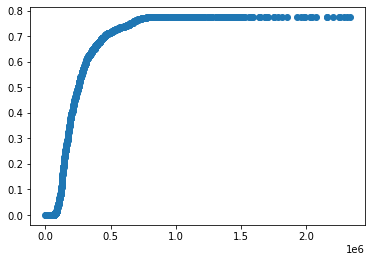

In [153]:
plt.scatter(ejection_df.columns,ejection_df.loc[ejection_df.index[4]])
#plt.xlim(0,0.3e6)

In [236]:
files=[
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260910_145258_0.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260910_145258_1.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260910_145258_2.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260910_145258_3.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260910_145258_4.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260910_145258_5.csv'


]

In [237]:
df=pd.DataFrame()
for file in files:
    temp_df=pd.read_csv(file)
    df=pd.concat([df,temp_df], ignore_index=True)

In [238]:
df

,m_planet,time,a,e
0,0.030027,9.853065e+04,Unbound,29.710378
1,0.030027,9.853065e+04,Unbound,68.876042
2,0.030027,9.853065e+04,Unbound,158.093086
3,0.030027,9.853065e+04,Unbound,38.948290
4,0.030027,9.853065e+04,Unbound,10.663730
...,...,...,...,...
594,0.000300,2.101684e+06,0.8734094907402526,0.310107
595,0.000300,2.101684e+06,4004.4950762769217,0.998891
596,0.000300,2.101684e+06,16306.991272176127,0.999555
597,0.000300,2.101684e+06,0.981687479476597,0.058577


In [239]:
bound_df.m_planet[1247]

0.00030027

In [240]:
bound_df=df[df.a != 'Unbound']

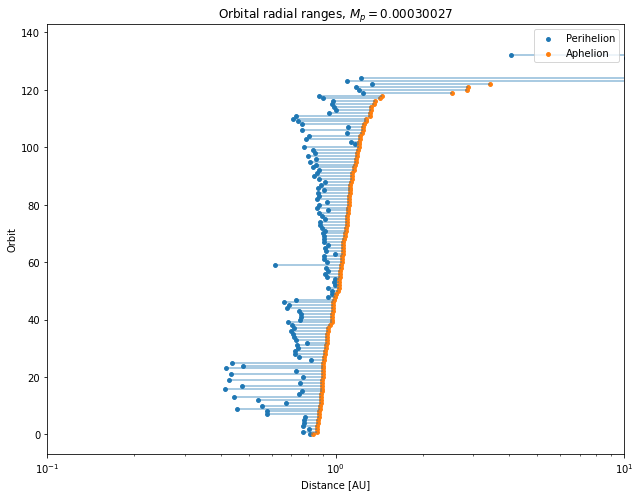

In [203]:


# Make sure a and e are numeric
plot_df = bound_df.copy()

plot_df["a"] = pd.to_numeric(plot_df["a"], errors="coerce")
plot_df["e"] = pd.to_numeric(plot_df["e"], errors="coerce")

# Remove unbound / invalid rows
plot_df = plot_df.dropna(subset=["a", "e"])
plot_df = plot_df[(plot_df["Q"] < 50_000) & (plot_df["e"] < 1)]

# Perihelion and aphelion
plot_df["q"] = plot_df["a"] * (1 - plot_df["e"])
plot_df["Q"] = plot_df["a"] * (1 + plot_df["e"])

# Select one planet mass
mass = 0.00030027
sub = plot_df[plot_df["m_planet"] == mass].copy()

# Optional: sort so progressively larger orbits are easier to see
sub = sub.sort_values("Q").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 7))

y = np.arange(len(sub))

# One horizontal line = radial range of one orbit
ax.hlines(
    y=y,
    xmin=sub["q"],
    xmax=sub["Q"],
    alpha=0.5
)

# Mark perihelion and aphelion
ax.scatter(sub["q"], y, s=15, label="Perihelion")
ax.scatter(sub["Q"], y, s=15, label="Aphelion")

ax.set_xlabel("Distance [AU]")
ax.set_ylabel("Orbit")
ax.set_title(f"Orbital radial ranges, $M_p={mass}$")
ax.set_xscale("log")

ax.legend()
ax.set_xlim(.1,10)

plt.tight_layout()
plt.show()

In [246]:
left_counts = ejection_df[ejection_df.columns[-1]]*800

unbound_counts = (
    df.groupby("m_planet")["a"]
    .apply(lambda x: (x == "Unbound").sum())
)


total_affected = left_counts.add(unbound_counts, fill_value=0)

In [242]:
a_num = pd.to_numeric(df["a"], errors="coerce")
e_num = pd.to_numeric(df["e"], errors="coerce")

df["Q"] = a_num * (1 + e_num)


In [243]:
aphelion_counts = (
    df.groupby("m_planet")["Q"]
      .apply(lambda x: (x > 50_000).sum())
)

In [244]:
total_affected= left_counts.add(aphelion_counts, fill_value=0)

In [247]:
total_affected= total_affected.add(aphelion_counts, fill_value=0)

In [248]:
total_affected

0.000300    692.0
0.000712    703.0
0.001689    725.0
0.004004    744.0
0.009496    769.0
0.030027    768.0
dtype: float64

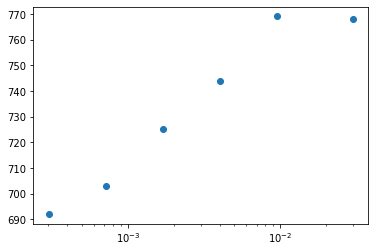

In [250]:
plt.scatter(total_affected.index,total_affected)
plt.xscale('log')

In [146]:
ejection_df

,0.000000e+00,1.970633e+03,2.985857e+03,2.997470e+03,3.981143e+03,3.992016e+03,4.998221e+03,4.999249e+03,5.911898e+03,5.988023e+03,...,2.089686e+06,2.100685e+06,2.132680e+06,2.153677e+06,2.203669e+06,2.301654e+06,2.382642e+06,2.424636e+06,2.509623e+06,2.520622e+06
0.030027,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.64750,0.64750,0.64750,0.64750,0.64750,0.64750,0.64750,0.64750,0.64750,0.64750
0.009496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.69625,0.69625,0.69625,0.69625,0.69625,0.69625,0.69625,0.69625,0.69625,0.69625
0.004004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.70625,0.70625,0.70625,0.70625,0.70625,0.70625,0.70625,0.70625,0.70625,0.70625
0.001689,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.84875,0.84875,0.84875,0.84875,0.84875,0.84875,0.84875,0.84875,0.84875,0.84875
0.000712,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.87875,0.87875,0.87875,0.87875,0.87875,0.87875,0.87875,0.87875,0.87875,0.87875
0.000300,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.92250,0.92375,0.92500,0.92625,0.92750,0.92875,0.93000,0.93125,0.93250,0.93375


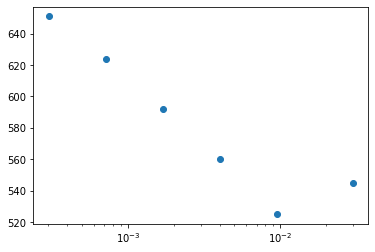

In [189]:
plt.scatter(total_affected.index,total_affected)
plt.xscale('log')

In [164]:
popt,pcov=curve_fit(log_fit,total_affected.index,total_affected)

In [166]:
popt[0]

-37.369197352278455

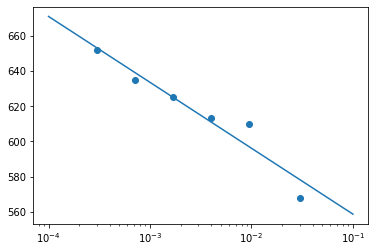

In [168]:
x=np.logspace(-4,-1,100)
y=log_fit(x,popt[0],popt[1])
plt.plot(x,y)
plt.scatter(total_affected.index,total_affected)
plt.xscale('log')

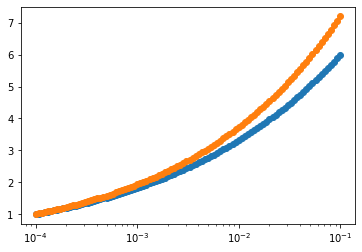

In [174]:
y2=y*x**(2/7)
y3=x**(2/7)
plt.scatter(x,y2/y2[0])
plt.scatter(x,y3/y3[0])
plt.xscale('log')

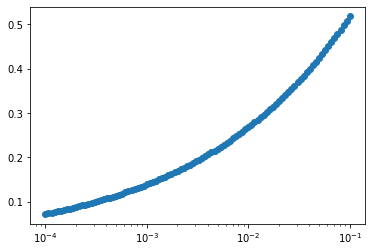

In [ ]:

plt.xscale('log')

In [12]:
def log_fit(q, a, b):
    return a * np.log10(q) + b

In [13]:
def e_frac_vs_mass(q):
    a=0.08509622694638502
    b=1.0913245932397357
    return a * np.log10(q) + b
def imf(Mstar):
    """Salpeter IMF, arbitrary normalization."""
    
    return 1000*Mstar**(-2.35)
def available_mass(M_star):
    """Moro_Martin 2018 Section 3.2.1"""
    return 1e-4*M_star

In [14]:
def integrated_ejection_mass(masses, e_frac=e_frac_vs_mass, imf=imf, planet_mass=0.000954588):
    weights=imf(masses)
    fractions=e_frac(planet_mass/masses)
    disc_mass=available_mass(masses)

    average_ejected_mass = np.trapz(weights * fractions * disc_mass, x=masses)/ np.trapz(weights, x=masses)
    return average_ejected_mass

In [15]:
masses = np.logspace(
    np.log10(0.08),
    np.log10(100),
    10000)

In [16]:
stellar_densities = np.array([
    0.08,
    6.0,
    326
])

# Planet masses [M_sun]
planet_masses = np.array([
    3.003e-6,      # Earth
    9.54588e-4,    # Jupiter
])

# Labels for table
planet_labels = [
    r"1 M_Earth",
    r"1 M_Jupiter"
]

table = pd.DataFrame(
    index=stellar_densities,
    columns=planet_labels,
    dtype=float
)

for density in stellar_densities:
    for planet_mass, label in zip(planet_masses, planet_labels):

        mass_per_star = integrated_ejection_mass(
            masses,
            planet_mass=planet_mass
        )

        table.loc[density, label] = f"{density * mass_per_star * 333030:.4f}"

table.index.name = "Stellar Density [stars / pc^3]"

table

/var/folders/vk/2xktddx11s99wx6wl7rlmm9c0000gn/T/ipykernel_49175/3147123783.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4774' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.loc[density, label] = f"{density * mass_per_star * 333030:.4f}"
/var/folders/vk/2xktddx11s99wx6wl7rlmm9c0000gn/T/ipykernel_49175/3147123783.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6380' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.loc[density, label] = f"{density * mass_per_star * 333030:.4f}"


,1 M_Earth,1 M_Jupiter
Stellar Density [stars / pc^3],,
0.08,0.4774,0.6380
6.00,35.8041,47.8517
326.00,1945.3574,2599.9447


In [22]:
def a_distribution(a, C=350,beta=-0.86,a_0=3.6, gamma=1.59):
    prefactor=C*a**beta
    term_2=(1-np.exp(-(a/a_0)**gamma))
    return prefactor*term_2
def surface_density(a, r=-1):
    return a**r

    

In [24]:
def fulton_a(a, beta = -0.86,a0 = 3.6,gamma = 1.58):

    return (
        a**beta
        * (1 - np.exp(-(a / a0)**gamma))
    )
def log_normalized_fulton_a(
    beta=-0.86,
    a0=3.6,
    gamma=1.58,
    a_min=np.log10(0.03),
    a_max=np.log10(30)
):
    a = np.logspace(a_min, a_max, 1000)
    log_a = np.log10(a)

    fa = fulton_a(a)

    p_a = fa / np.trapz(fa, x=log_a)

    return a, p_a

In [30]:
a, p_a = log_normalized_fulton_a()

np.trapz(p_a, x=np.log10(a))

1.0

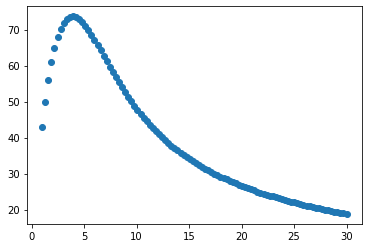

In [21]:
x=np.linspace(1,30,100)
y=a_distribution(x)
plt.scatter(x,y)

In [ ]:
def chaotic_zone_mass_fraction(
    Mstar,
    a_planet,
    planet_mass,
    surface_density=surface_density,
    r_disc_min=0.01,
    r_disc_max=30,
    n=1000,
):
    q = planet_mass / Mstar

    delta_a = 1.3 * q**(2/7) * a_planet

    mass_fraction=(2*delta_a)/(r_disc_max-r_disc_min)

    # cz_min = max(a_planet - delta_a, r_disc_min)
    # cz_max = min(a_planet + delta_a, r_disc_max)


    # # Mass in chaotic zone
    # r_cz = np.linspace(cz_min, cz_max, n)
    # sigma_cz = surface_density(r_cz, Mstar)

    # M_cz = np.trapz(
    #     2 * np.pi * r_cz * sigma_cz,
    #     x=r_cz
    # )

    # # Total disk mass represented by surface-density model
    # r_disc = np.linspace(r_disc_min, r_disc_max, n)
    # sigma_disc = surface_density(r_disc, Mstar)

    # M_disc = np.trapz(
    #     2 * np.pi * r_disc * sigma_disc,
    #     x=r_disc
    # )
    r_disc = np.linspace(r_disc_min, r_disc_max, n)
    np.trapz()

    return M_cz / M_disc

In [ ]:
def average_chaotic_zone_fraction(m_star, planet_mass):
    a, p_a = log_normalized_fulton_a()
    q=planet_mass/m_star
    cz_fractions = (
    2 * 1.3 * q**(2/7) * a
    / (r_disc_max - r_disc_min)
    )

    average_fraction = np.trapz(
        p_a * cz_fractions,
        x=np.log10(a)
    )

    return average_fraction

In [124]:
def average_chaotic_zone_fraction(m_star, planet_mass, a_min=0.03,a_max=30,r_disc_max = 50 ,r_disc_min=0.01):
    a = np.logspace(np.log10(a_min), np.log10(a_max), 1000)

    F = fulton_a(a)  # raw Fulton dN/dln(a)

    q = planet_mass / m_star

    cz_fractions = (
        2 * 1.3 * q**(2/7)
        / (r_disc_max - r_disc_min)
    )

    numerator = np.trapz(
        cz_fractions * F,
        x=a
    )

    denominator = np.trapz(
        F / a,
        x=a
    )

    return numerator / denominator

In [134]:

r_disc_max=100
a_max=r_disc_max/(1+1.3*0.001**(2/7))
r_disc_min=0.01
a_min=r_disc_min/(1-1.3*0.001**(2/7))
average_chaotic_zone_fraction(1.0,0.001,a_min=a_min,a_max=a_max,r_disc_max = r_disc_max ,r_disc_min=r_disc_min)

0.025809846960449558

In [133]:
a_max

84.7002245499997

In [94]:
average_chaotic_zone_fraction(1, 0.001)

0.03613957411067788